In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/customer_cleaned.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1000, 8)


,name,age,gender,education,income,country,purchase_frequency,annual_spending
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780


In [2]:
clustering_features = [
    "age",
    "income",
    "purchase_frequency",
    "annual_spending"
]

X = df[clustering_features].copy()

print("Selected features:")
print(X.columns.tolist())

print("\nFeature matrix shape:")
print(X.shape)

X.head()

Selected features:
['age', 'income', 'purchase_frequency', 'annual_spending']

Feature matrix shape:
(1000, 4)


,age,income,purchase_frequency,annual_spending
0,42,53936,0.9,13227.120
1,49,82468,0.6,12674.040
2,55,56941,0.3,5354.115
3,24,60651,0.2,2606.510
4,64,81884,0.9,18984.780


In [3]:
from sklearn.preprocessing import StandardScaler

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=clustering_features
)

X_scaled.head()

,age,income,purchase_frequency,annual_spending
0,0.017863,-0.229789,1.213920,0.659221
1,0.526152,0.997565,0.159560,0.558330
2,0.961828,-0.100524,-0.894801,-0.776944
3,-1.289166,0.059068,-1.246254,-1.278153
4,1.615343,0.972444,1.213920,1.709512


In [5]:
print("Means after standardization:")
print(X_scaled.mean())

print("\nStandard deviations after standardization:")
print(X_scaled.std())

Means after standardization:
age                   1.634248e-16
income                3.552714e-17
purchase_frequency    8.704149e-17
annual_spending      -1.865175e-16
dtype: float64

Standard deviations after standardization:
age                   1.0005
income                1.0005
purchase_frequency    1.0005
annual_spending       1.0005
dtype: float64


In [6]:
from sklearn.decomposition import PCA


In [7]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.48520819 0.26192438 0.23446463 0.01840281]


In [8]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print("Cumulative explained variance:")
print(cumulative_variance)

Cumulative explained variance:
[0.48520819 0.74713257 0.98159719 1.        ]


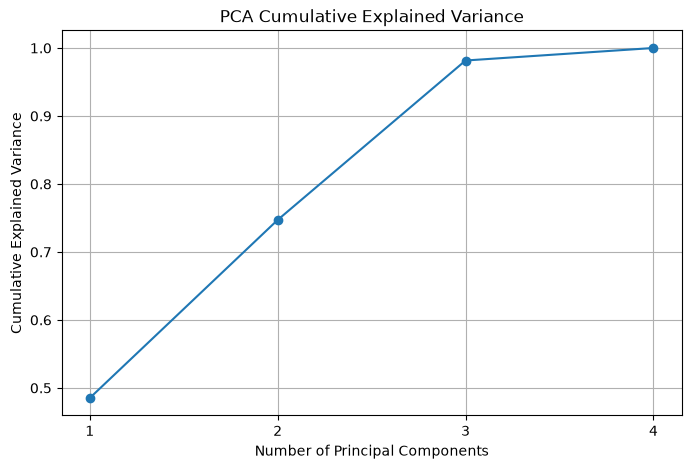

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)

plt.show()

In [10]:
pca_3 = PCA(n_components=3)

X_pca_3 = pca_3.fit_transform(X_scaled)

X_pca_3 = pd.DataFrame(
    X_pca_3,
    columns=["PC1", "PC2", "PC3"]
)

print("PCA feature matrix shape:", X_pca_3.shape)

X_pca_3.head()

PCA feature matrix shape: (1000, 3)


,PC1,PC2,PC3
0,1.266273,-0.081795,-0.484660
1,0.701738,0.371163,0.982383
2,-0.984964,-0.803763,0.844999
3,-1.977845,0.830040,-0.478207
4,2.426506,-0.312229,1.401481


In [11]:
loadings = pd.DataFrame(
    pca_3.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=clustering_features
)

print("PCA Loadings:")
display(loadings)

PCA Loadings:


,PC1,PC2,PC3
age,0.185806,-0.686760,0.682446
income,0.102934,0.722418,0.678819
purchase_frequency,0.677437,0.080439,-0.270377
annual_spending,0.704244,-0.001774,-0.019188


In [12]:
X_scaled.to_csv(
    "../data/customer_scaled_features.csv",
    index=False
)

X_pca_3.to_csv(
    "../data/customer_pca_features.csv",
    index=False
)

print("Feature datasets saved successfully.")

Feature datasets saved successfully.
